# Phase 1

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
# Read the movie ratings data as CSV
columns = ["userId", "movieId", "categoryId", "reviewId", "movieRating", "reviewDate"]

df = pd.read_csv("./data/movie-ratings.txt", header=None, names=columns)
df.head()

,userId,movieId,categoryId,reviewId,movieRating,reviewDate
0,1,1,1,1,5,2000-07-12
1,2,1,1,2,5,2000-07-12
2,3,1,1,3,5,2000-07-12
3,4,1,1,4,4,2000-07-12
4,5,1,1,5,4,2000-07-12


In [3]:
# Basic statistics: number of users, movies, ratings, and sparsity
n_users = df['userId'].nunique()
n_movies = df['movieId'].nunique()
n_ratings = len(df)

# Sparsity = (total possible ratings - actual ratings) / total possible ratings
total_possible = n_users * n_movies
sparsity = 1 - (n_ratings / total_possible)

print("=== Dataset Statistics ===")
print(f"Number of users: {n_users}")
print(f"Number of movies: {n_movies}")
print(f"Number of ratings: {n_ratings}")
print(f"Sparsity of rating matrix: {sparsity:.4f} ({sparsity*100:.2f}%)")

=== Dataset Statistics ===
Number of users: 17615
Number of movies: 16121
Number of ratings: 72665
Sparsity of rating matrix: 0.9997 (99.97%)


In [4]:
# Basic statistics of the dataframe
print("=== Basic Statistics ===")
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDescriptive statistics:\n{df.describe()}")

=== Basic Statistics ===
Shape: (72665, 6)

Data types:
userId          int64
movieId         int64
categoryId      int64
reviewId        int64
movieRating     int64
reviewDate     object
dtype: object

Missing values:
userId         0
movieId        0
categoryId     0
reviewId       0
movieRating    0
reviewDate     0
dtype: int64

Descriptive statistics:
             userId       movieId    categoryId      reviewId   movieRating
count  72665.000000  72665.000000  72665.000000  72665.000000  72665.000000
mean    4279.437597   8076.878786     12.659300  36333.000000      4.072910
std     4620.200449   4397.176683      4.158915  20976.722992      1.081442
min        1.000000      1.000000      1.000000      1.000000      1.000000
25%      857.000000   4632.000000     11.000000  18167.000000      4.000000
50%     2102.000000   7623.000000     14.000000  36333.000000      4.000000
75%     6568.000000  12105.000000     16.000000  54499.000000      5.000000
max    17615.000000  16121.000000

In [6]:
# Handle missing values by filling with median rating for that movieId
print(f"Missing values before: {df['movieRating'].isnull().sum()}")

# Calculate median rating per movieId
movie_medians = df.groupby('movieId')['movieRating'].median()

# Fill missing values with the median rating for that movieId
def fill_missing_with_median(row):
    if pd.isnull(row['movieRating']):
        return movie_medians.get(row['movieId'], df['movieRating'].median())
    return row['movieRating']

df['movieRating'] = df.apply(fill_missing_with_median, axis=1)

print(f"Missing values after: {df['movieRating'].isnull().sum()}")

Missing values before: 0
Missing values after: 0


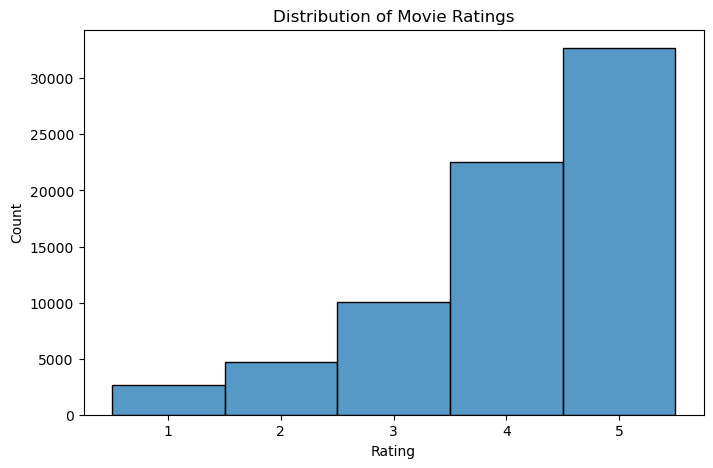

In [21]:
# Histogram of ratings
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['movieRating'], bins=5, discrete=True, edgecolor='black')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

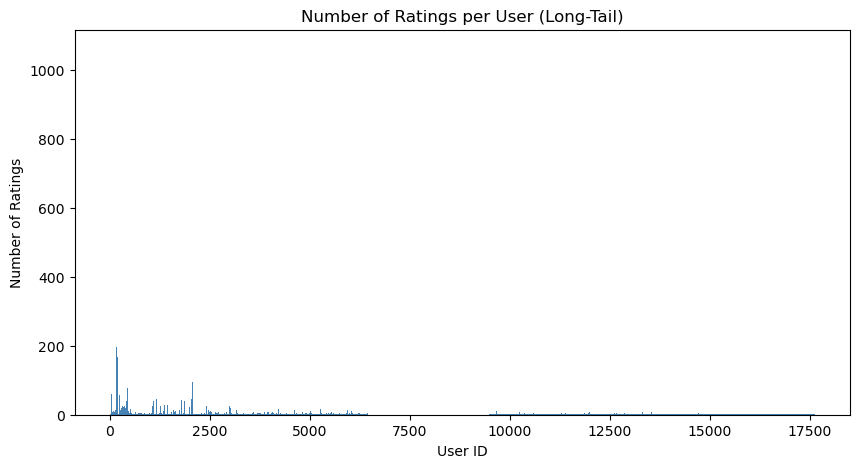

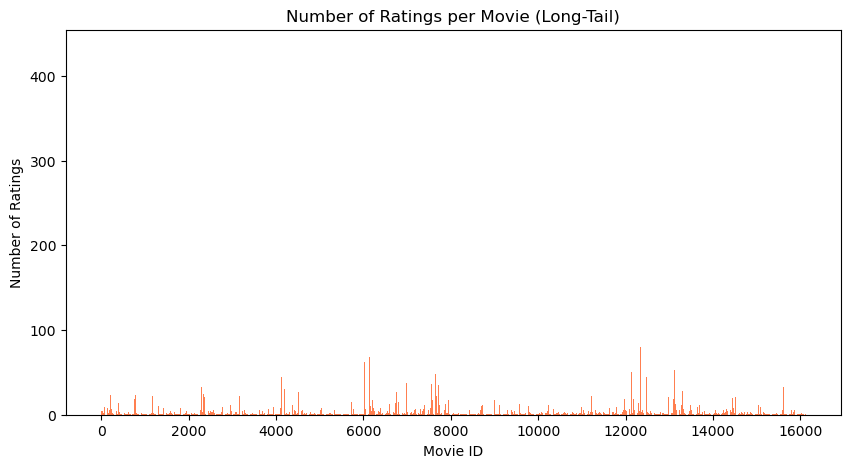

In [ ]:
# Not sure if this is right. Not sure what the intended outcome is supposed to be

# Visualize ratings per user (long-tail distribution)
user_counts = df.groupby('userId').size()

plt.figure(figsize=(10, 5))
plt.bar(user_counts.index, user_counts.values, color='steelblue')
plt.title('Number of Ratings per User (Long-Tail)')
plt.xlabel('User ID')
plt.ylabel('Number of Ratings')
plt.show()

# Visualize ratings per movie (long-tail distribution)
movie_counts = df.groupby('movieId').size()

plt.figure(figsize=(10, 5))
plt.bar(movie_counts.index, movie_counts.values, color='coral')
plt.title('Number of Ratings per Movie (Long-Tail)')
plt.xlabel('Movie ID')
plt.ylabel('Number of Ratings')
plt.show()

# Phase 2

In [4]:
# Install scikit-surprise if not available
try:
    from surprise import Dataset, Reader, SVD, BaselineOnly
    from surprise.model_selection import cross_validate, train_test_split
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'scikit-surprise'])
    from surprise import Dataset, Reader, SVD, BaselineOnly
    from surprise.model_selection import cross_validate, train_test_split

# Prepare data for Surprise library
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df[['userId', 'movieId', 'movieRating']], reader)

# Build full trainset
trainset = data.build_full_trainset()

print("=== Global Average Algorithm ===")
# Global Average baseline
global_avg = BaselineOnly(bsl_options={'method': 'global_avg'})
global_avg.fit(trainset)
print(f"Global average rating: {global_avg.predict(uid=1, iid=1).est:.4f}")

print("\n=== SVD Algorithm ===")
# SVD algorithm
svd = SVD(n_factors=100, n_epochs=20, random_state=42)
svd.fit(trainset)
print(f"SVD model trained with {trainset.n_users} users and {trainset.n_items} items")

# Example prediction
pred = svd.predict(uid=1, iid=1)
print(f"SVD prediction for user 1, movie 1: {pred.est:.4f}")

=== Global Average Algorithm ===
Estimating biases using global_avg...


ValueError: Invalid method global_avg for baseline computation. Available methods are als and sgd.